In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('../data/processed/featured.csv')
print(f"✅ Loaded! {df.shape[0]} rows × {df.shape[1]} columns")

✅ Loaded! 19548 rows × 41 columns


In [2]:
features = [
    'Danceability', 'Energy', 'Loudness', 'Speechiness',
    'Acousticness', 'Instrumentalness', 'Liveness', 'Valence',
    'Tempo', 'duration_min', 'engagement_ratio',
    'energy_dance', 'positivity_score',
    'artist_platform_score', 'album_type_encoded',
    'gap_score'
]

# Target is log_streams — predicting stream count
X = df[features]
y = df['log_streams']

print(f"✅ Features shape : {X.shape}")
print(f"✅ Target shape   : {y.shape}")
print(f"\nTarget stats:")
print(y.describe())

✅ Features shape : (19548, 16)
✅ Target shape   : (19548,)

Target stats:
count    19548.000000
mean        17.647847
std          1.648901
min          8.791030
25%         16.696949
50%         17.727446
75%         18.754918
max         21.943069
Name: log_streams, dtype: float64


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"✅ Training set : {X_train.shape[0]} rows")
print(f"✅ Testing set  : {X_test.shape[0]} rows")

✅ Training set : 15638 rows
✅ Testing set  : 3910 rows


In [4]:
# Linear Regression finds a straight line relationship
# Simple but gives us a baseline to beat
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

lr_preds = lr_model.predict(X_test)

lr_rmse = np.sqrt(mean_squared_error(y_test, lr_preds))
lr_r2   = r2_score(y_test, lr_preds)

print("✅ Linear Regression trained!")
print(f"RMSE : {lr_rmse:.4f}")
print(f"R²   : {lr_r2:.4f}")

✅ Linear Regression trained!
RMSE : 1.5568
R²   : 0.1535


In [5]:
# Gradient Boosting builds trees one by one
# Each tree fixes the errors of the previous one
gbm_model = GradientBoostingRegressor(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    random_state=42
)

gbm_model.fit(X_train, y_train)

gbm_preds = gbm_model.predict(X_test)

gbm_rmse = np.sqrt(mean_squared_error(y_test, gbm_preds))
gbm_r2   = r2_score(y_test, gbm_preds)

print("✅ Gradient Boosting trained!")
print(f"RMSE : {gbm_rmse:.4f}")
print(f"R²   : {gbm_r2:.4f}")

✅ Gradient Boosting trained!
RMSE : 1.4137
R²   : 0.3020


✅ Model Comparison:
               Model      RMSE        R²
0  Linear Regression  1.556820  0.153480
1  Gradient Boosting  1.413651  0.302017


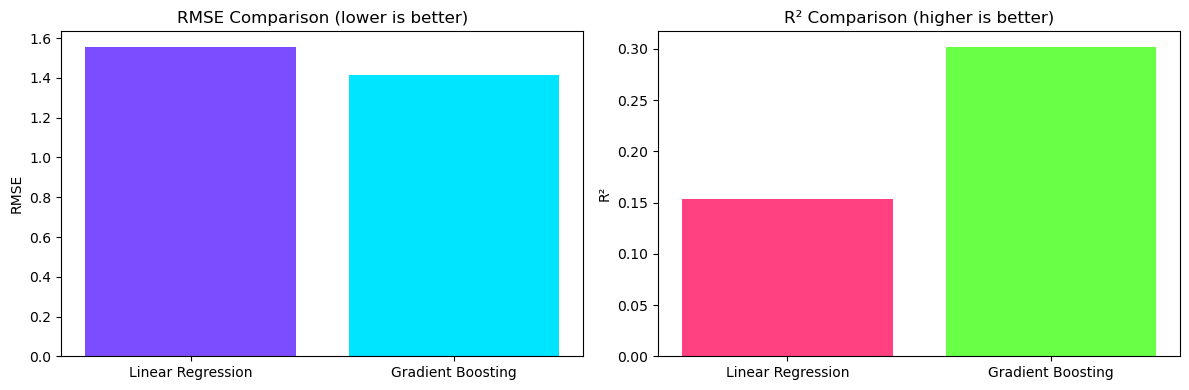

✅ Saved!


In [6]:
# Side by side comparison of both models
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Gradient Boosting'],
    'RMSE' : [lr_rmse, gbm_rmse],
    'R²'   : [lr_r2,   gbm_r2]
})

print("✅ Model Comparison:")
print(results)

# Bar chart
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(results['Model'], results['RMSE'], color=['#7c4dff','#00e5ff'])
axes[0].set_title('RMSE Comparison (lower is better)')
axes[0].set_ylabel('RMSE')

axes[1].bar(results['Model'], results['R²'], color=['#ff4081','#69ff47'])
axes[1].set_title('R² Comparison (higher is better)')
axes[1].set_ylabel('R²')

plt.tight_layout()
plt.savefig('../reports/figures/regression_comparison.png')
plt.show()
print("✅ Saved!")

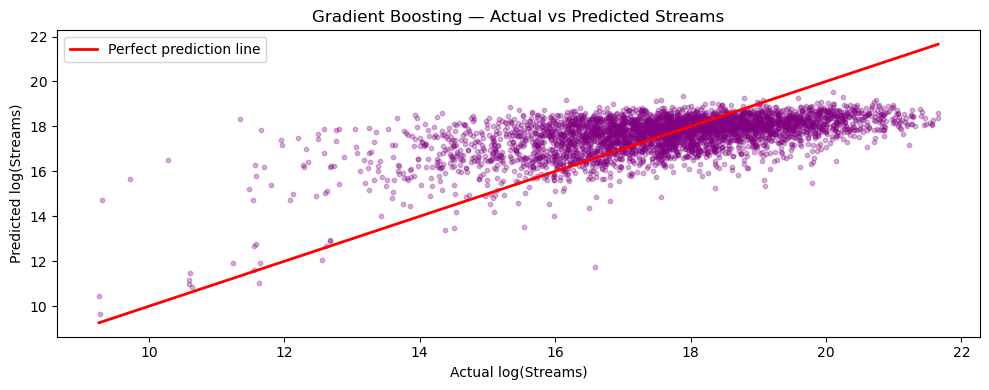

In [7]:
# This shows how close our predictions are to reality
plt.figure(figsize=(10, 4))

plt.scatter(y_test, gbm_preds, alpha=0.3, color='purple', s=10)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red', lw=2, label='Perfect prediction line')
plt.title('Gradient Boosting — Actual vs Predicted Streams')
plt.xlabel('Actual log(Streams)')
plt.ylabel('Predicted log(Streams)')
plt.legend()
plt.tight_layout()
plt.savefig('../reports/figures/actual_vs_predicted.png')
plt.show()

In [8]:
import pickle

with open('../models/gbm_regressor.pkl', 'wb') as f:
    pickle.dump(gbm_model, f)

print("✅ Gradient Boosting model saved to models/gbm_regressor.pkl")

✅ Gradient Boosting model saved to models/gbm_regressor.pkl
